# Thomas de Portzamparc - 30 dec 2025 

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import statsmodels.api as sm

from market_data_loader.data_handler import *
from market_data_loader.utils import *
from european_option import *
import numpy as np 

# Data analysis 

Here’s a short descriptive comment on the stocks we’ll analyze:

* **LVMH (MC.PA)** – Luxury leader; cyclical, sentiment and FX sensitive.
* **Danone (BN.PA)** – Defensive consumer staples; typically steadier, event-driven moves.
* **Siemens (SIE.DE)** – Industrial/automation; cycle and macro (capex/PMIs) sensitive.
* **AXA (CS.PA)** – Insurer; exposed to rates and risk sentiment.
* **Engie (ENGI.PA)** – Utility/energy; impacted by regulation and energy-price shocks.
* **Société Générale (GLE.PA)** – Bank; higher tail risk, usually steeper put skew.
* **BNP Paribas (BNP.PA)** – Bank; rate/credit sensitive, often elevated skew in stress.
* **L’Oréal (OR.PA)** – Consumer/luxury beauty; quality growth, generally smoother vol profile.



In [2]:
# To get our market data we've created a class in the market_data_loader folder to go on the internet and run some basic econometrics analysis


tickers = ['MC.PA', 'BN.PA', 'SIE.DE', 'CS.PA', 'ENGI.PA', 'GLE.PA', 'BNP.PA', 'OR.PA', "^FCHI"]
handler = OnlineDataHandler(tickers, macro_region="europe", start ="2017-04-06", end ="2018-04-06")
handler.load_data()

print("\nDernier bar pour Hermes :")
print(handler.get_latest_bar('MC.PA'))

print("\nVariables macroéconomiques :")
print(handler.macro_data.tail())

- Loading market data (1Day)...
MC.PA: 253 obs from Yahoo Finance (2017-04-06 → 2018-04-05) [1Day]
BN.PA: 253 obs from Yahoo Finance (2017-04-06 → 2018-04-05) [1Day]
SIE.DE: 253 obs from Yahoo Finance (2017-04-06 → 2018-04-05) [1Day]
CS.PA: 253 obs from Yahoo Finance (2017-04-06 → 2018-04-05) [1Day]
ENGI.PA: 253 obs from Yahoo Finance (2017-04-06 → 2018-04-05) [1Day]
GLE.PA: 253 obs from Yahoo Finance (2017-04-06 → 2018-04-05) [1Day]
BNP.PA: 253 obs from Yahoo Finance (2017-04-06 → 2018-04-05) [1Day]
OR.PA: 253 obs from Yahoo Finance (2017-04-06 → 2018-04-05) [1Day]
^FCHI: 253 obs from Yahoo Finance (2017-04-06 → 2018-04-05) [1Day]

Market data successfully loaded
Tickers: 9 | Period: 2017-04-06 → 2018-04-05
Observations: 253 | Timeframe: 1Day
- Loading macroeconomic data (EUROPE)...
[WARN] M1SUPPLY (MABMM201EZM189S): Unable to read URL: https://fred.stlouisfed.org/graph/fredgraph.csv?id=MABMM201EZM189S Response Text: b'<!DOCTYPE html>\r\n<html lang="en">\r\n<head>\r\n    <me
[WARN] CC

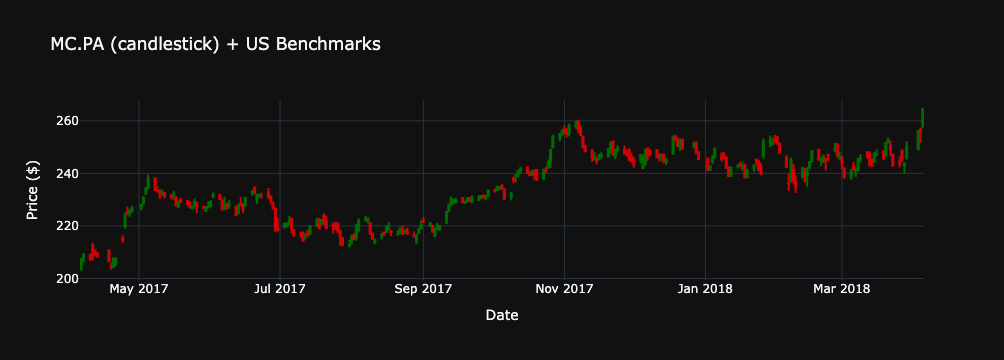

In [3]:
# Plot function for the stock we've picked 
plot_candlestick_with_indices(udl="MC.PA",  indices_dict =handler.price_all_dict, other = [])

In [4]:
price = handler.price_close_df
macro_factor = handler.macro_data
print(macro_factor.columns)
return_df = handler.return_close_df

Index(['CPI', 'INDPPI', 'AAA10Y', 'TB3MS', 'INF', 'DP', 'TS', 'DT', 'DI',
       'RF'],
      dtype='object')


<Axes: xlabel='DATE'>

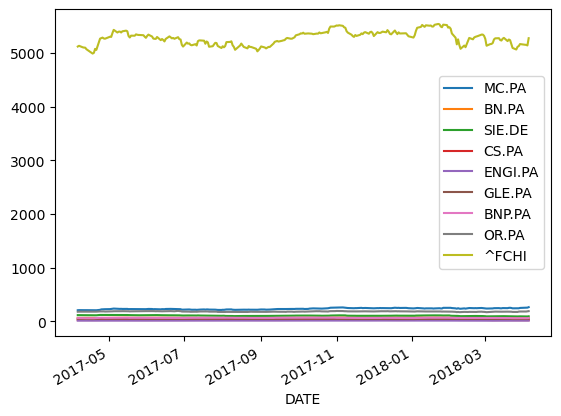

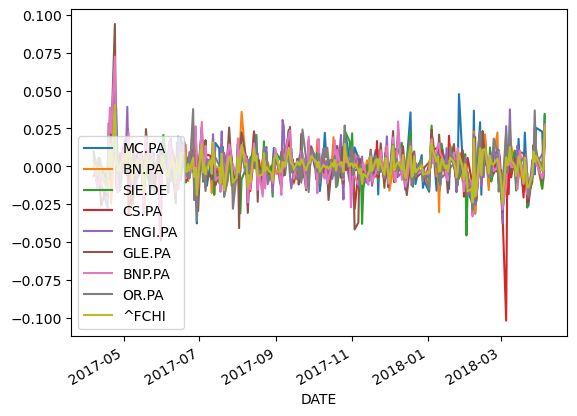

In [5]:
price.plot()
return_df.plot()

In [6]:
columns_actions = ['MC.PA', 'BN.PA', 'SIE.DE', 'CS.PA', 'ENGI.PA', 'GLE.PA', 'BNP.PA', 'OR.PA']
columns_index = ["^FCHI"]

In [7]:
df_econom = pd.merge(
    macro_factor,
    return_df,
    left_index=True,
    right_index=True,
    how="inner"   # ou "left" selon ton besoin
)
col_excess = []
for col in columns_actions: 
    df_econom[f"R{col}_excess"] = df_econom[col] - df_econom['RF']
    col_excess.append(f"R{col}_excess")
for col in columns_index: 
    df_econom[f"R{col}_excess"] = df_econom[col] - df_econom['RF']
    

df_econom = df_econom[['INF', 'DP', 'TS',
       'DT', 'DI','RMC.PA_excess', 'RBN.PA_excess',
       'RSIE.DE_excess', 'RCS.PA_excess', 'RENGI.PA_excess', 'RGLE.PA_excess',
       'RBNP.PA_excess', 'ROR.PA_excess', 'R^FCHI_excess']]

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def plot_vs_market_actual_fitted(
    models_dict,
    df,
    market_col="R^FCHI_excess",
    cols=None,
    alpha_points=0.55,
    sort_x=True,
):
    """
    One figure per underlying:
      - scatter: actual Y vs X (market factor)
      - line: fitted Yhat vs X (sorted by X for readability)
      - title/legend include alpha, beta and p-values (const + market factor)

    Works for both CAPM and APT dictionaries, as long as market_col is in the regression.
    """
    if cols is None:
        cols = list(models_dict.keys())

    if market_col not in df.columns:
        raise ValueError(f"'{market_col}' not found in df columns.")

    for col in cols:
        res = models_dict[col]

        if market_col not in res.params.index:
            raise ValueError(f"'{market_col}' not found in model params for {col}.")

        x_all = df[market_col]
        y_all = df[col]
        yhat_all = res.fittedvalues

        # align indices
        idx = x_all.index.intersection(y_all.index).intersection(yhat_all.index)
        x = x_all.loc[idx].astype(float).values
        y = y_all.loc[idx].astype(float).values
        yhat = yhat_all.loc[idx].astype(float).values

        # alpha/beta + p-values
        alpha_hat = float(res.params.get("const", np.nan))
        p_alpha = float(res.pvalues.get("const", np.nan))
        beta_hat = float(res.params.get(market_col, np.nan))
        p_beta = float(res.pvalues.get(market_col, np.nan))
        r2 = float(getattr(res, "rsquared", np.nan))

        # sort by X for a clean fitted line
        if sort_x:
            order = np.argsort(x)
            xs, ys, yhats = x[order], y[order], yhat[order]
        else:
            xs, ys, yhats = x, y, yhat

        plt.figure(figsize=(9, 6))

        # actual
        plt.scatter(xs, ys, s=18, alpha=alpha_points, label="Actual")

        # fitted (line)
        plt.plot(xs, yhats, linewidth=2.0, label="Fitted")

        # axes lines
        plt.axhline(0, linewidth=1)
        plt.axvline(0, linewidth=1)
        plt.grid(True, alpha=0.25)

        plt.xlabel(market_col)
        plt.ylabel(col)

        title = (
            f"{col} | Actual vs Fitted vs {market_col}\n"
            f"alpha={alpha_hat:.4g} (p={p_alpha:.3g}) | "
            f"beta={beta_hat:.4g} (p={p_beta:.3g}) | "
            f"R²={r2:.3f}"
        )
        plt.title(title)

        plt.legend()
        plt.tight_layout()
        plt.show()



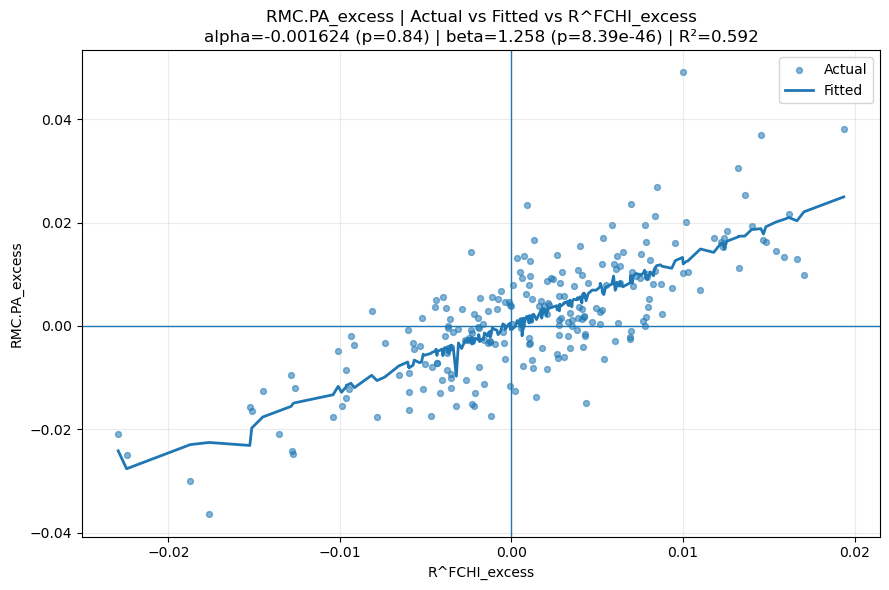

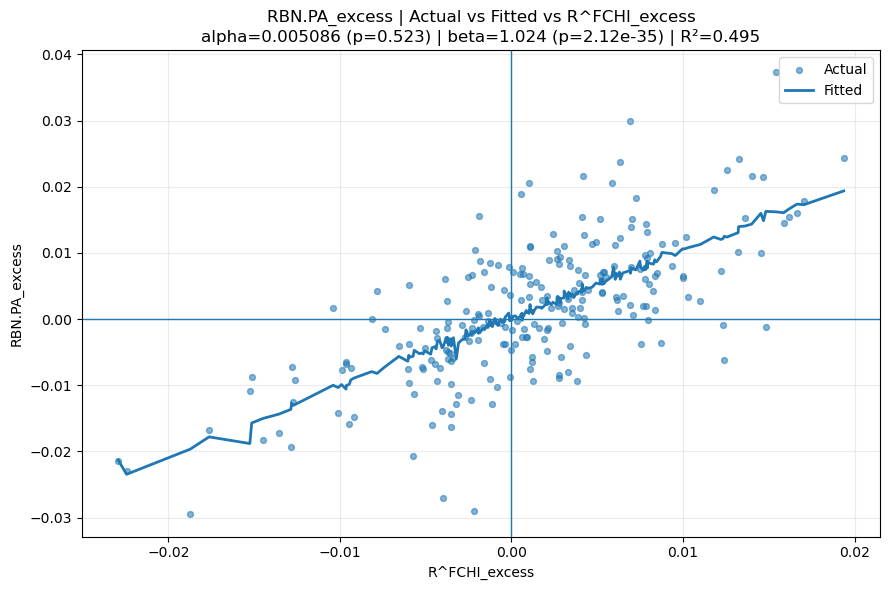

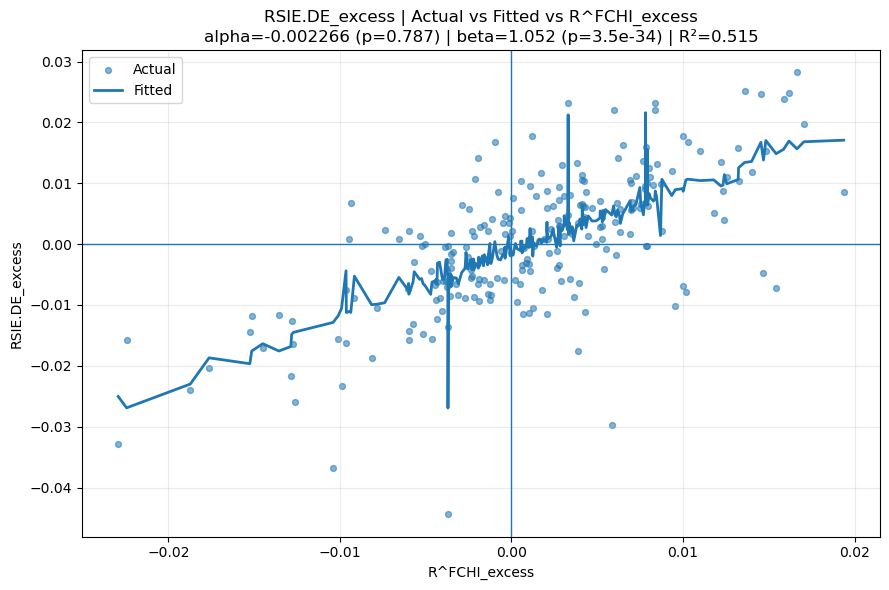

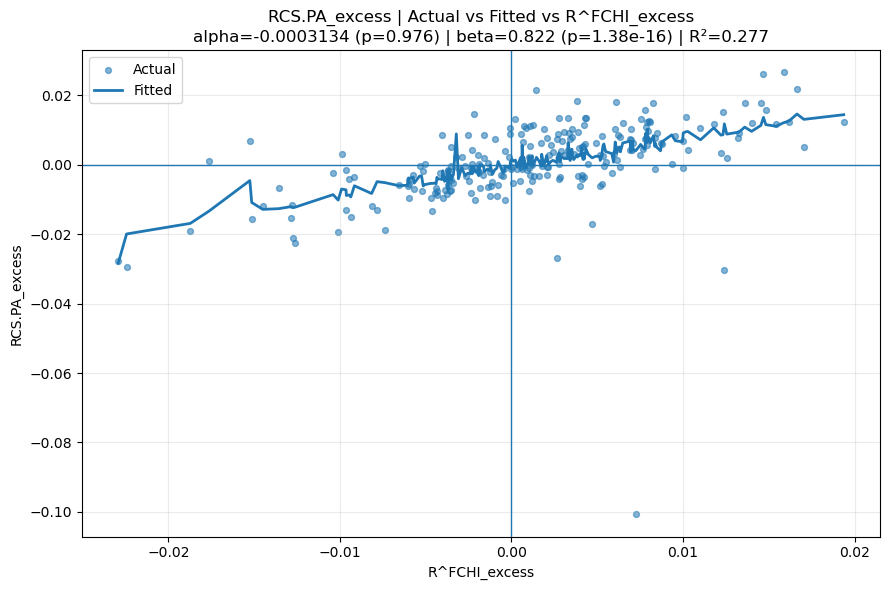

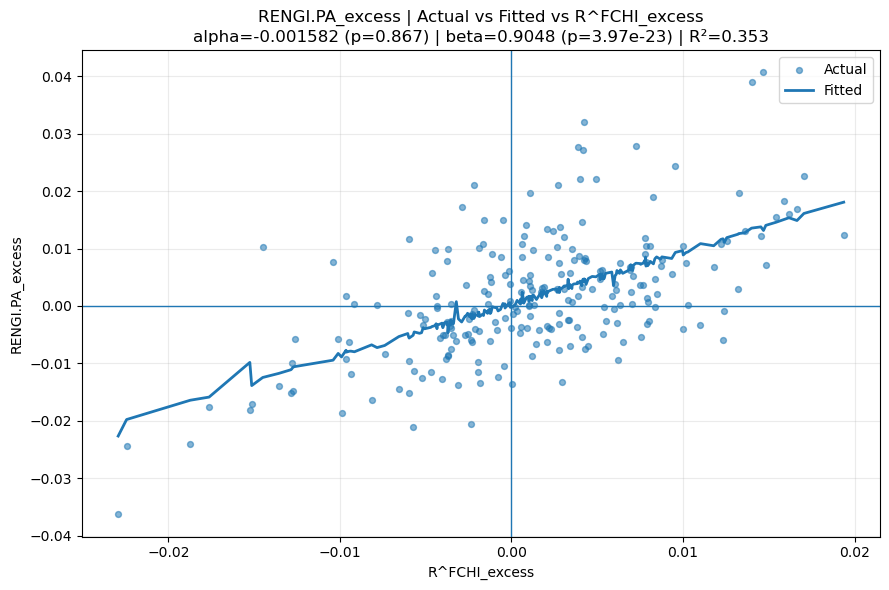

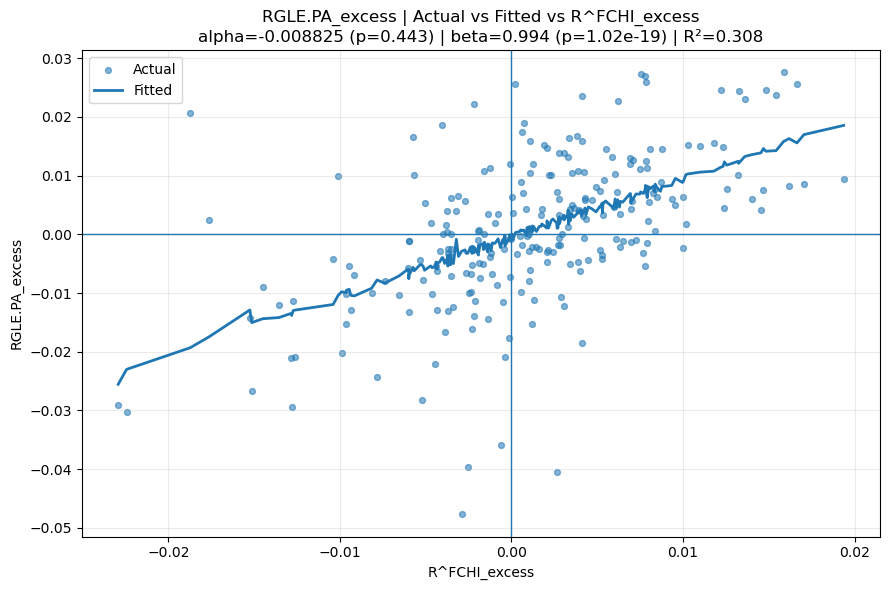

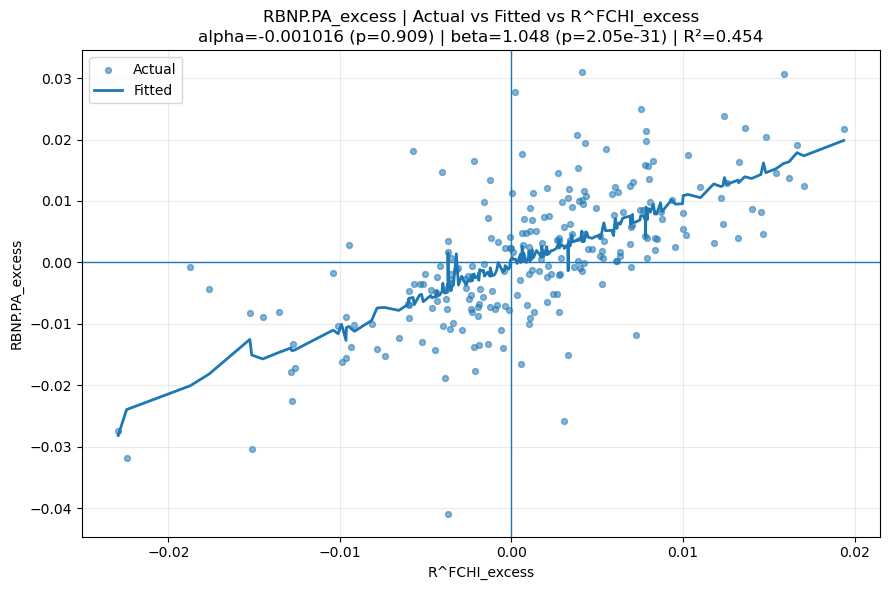

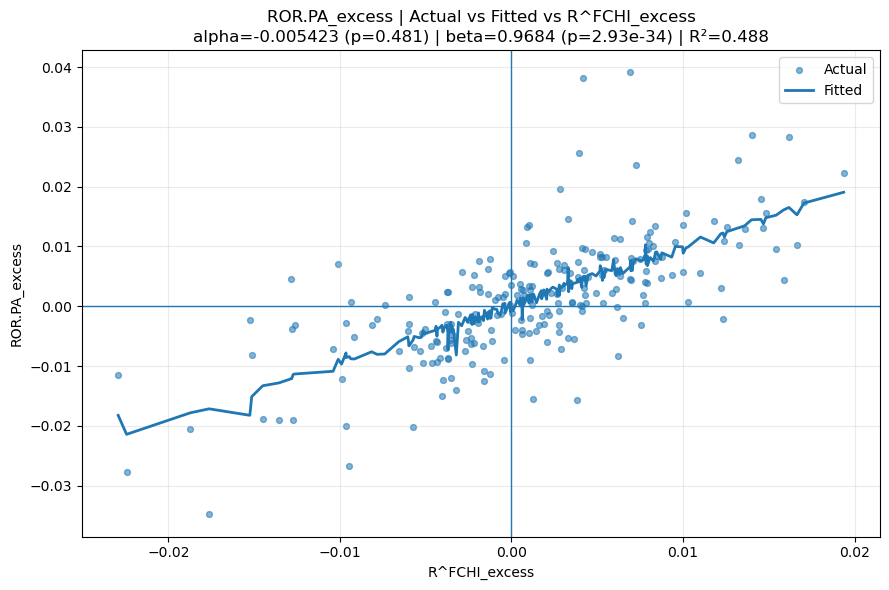

In [9]:
# 8) Estimate the APT model
import statsmodels.api as sm
apt_model= {}
# Define dependent and explanatory variables
for col in col_excess : 
    Y = df_econom[col]
    X_vars = ['R^FCHI_excess', 'INF', 'DP', 'DT', 'TS', 'DI']
    
    X = df_econom[X_vars]
    X = sm.add_constant(X)  # add intercept
    
    # Fit OLS regression
    apt_model[col] = sm.OLS(Y, X).fit()
    
    # Display summary
    #print(apt_model[col].summary())
plot_vs_market_actual_fitted(apt_model, df_econom)


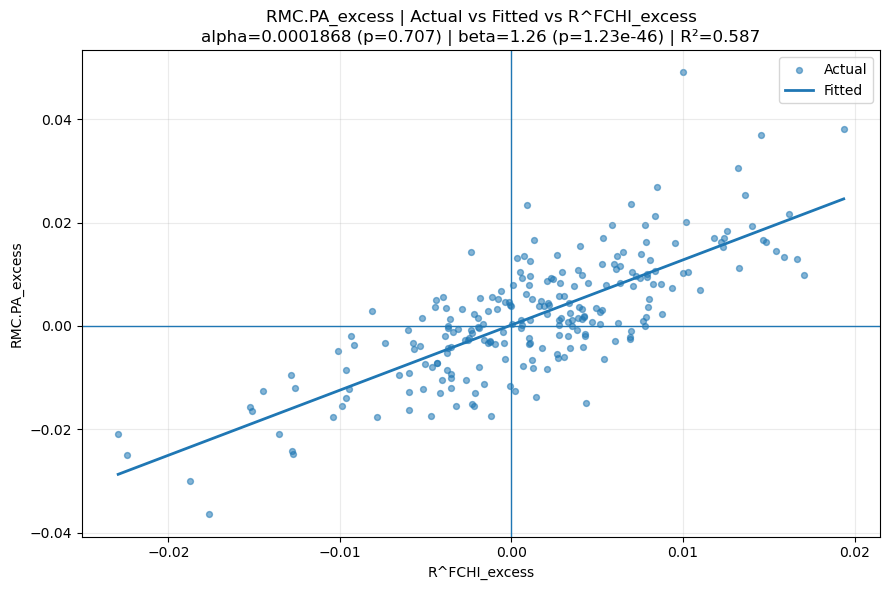

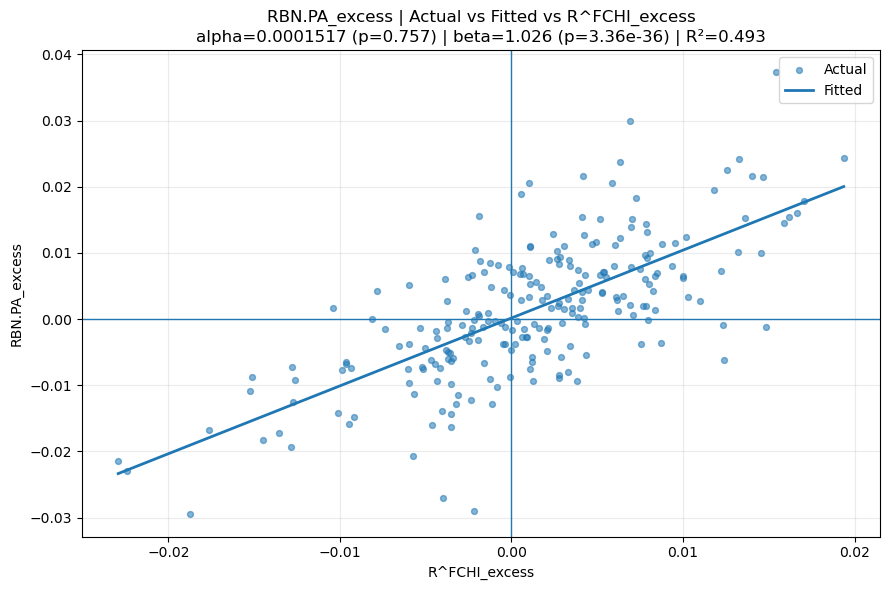

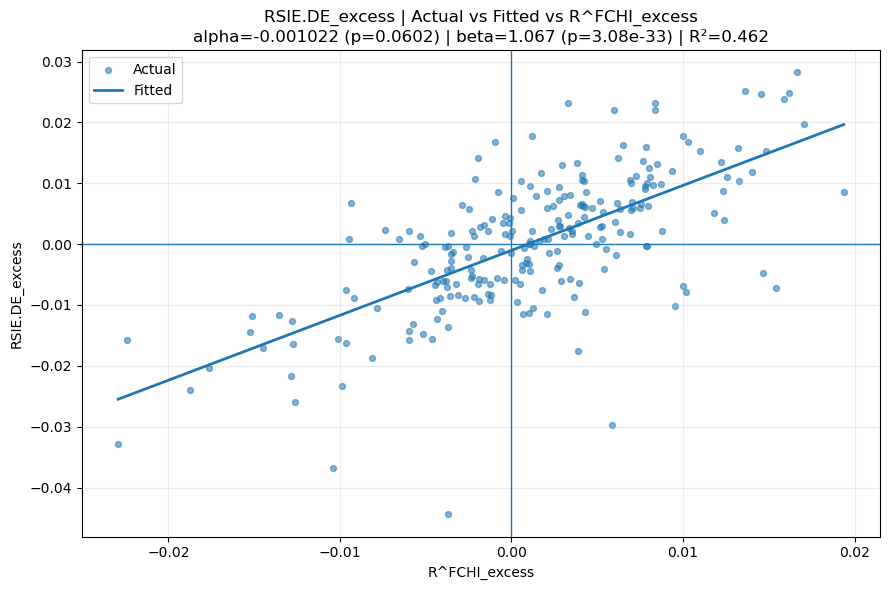

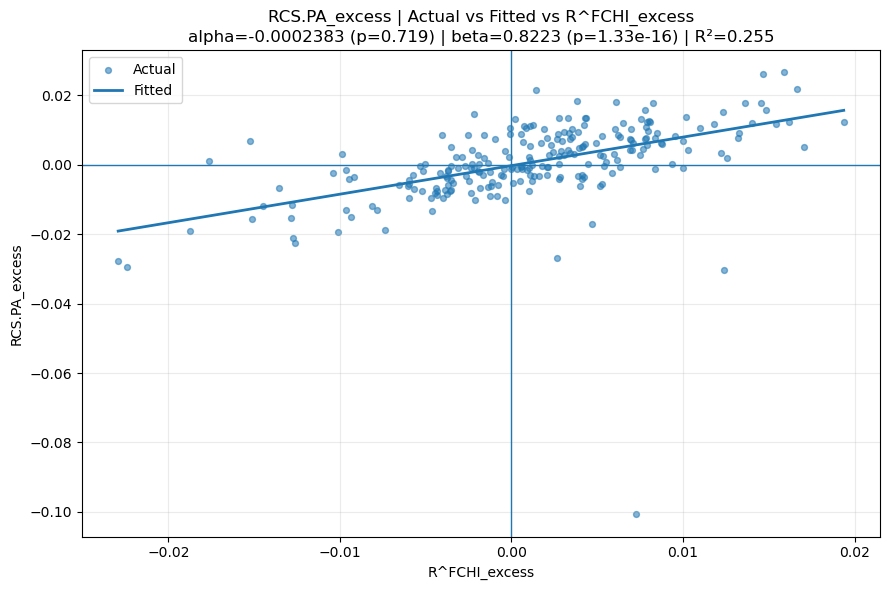

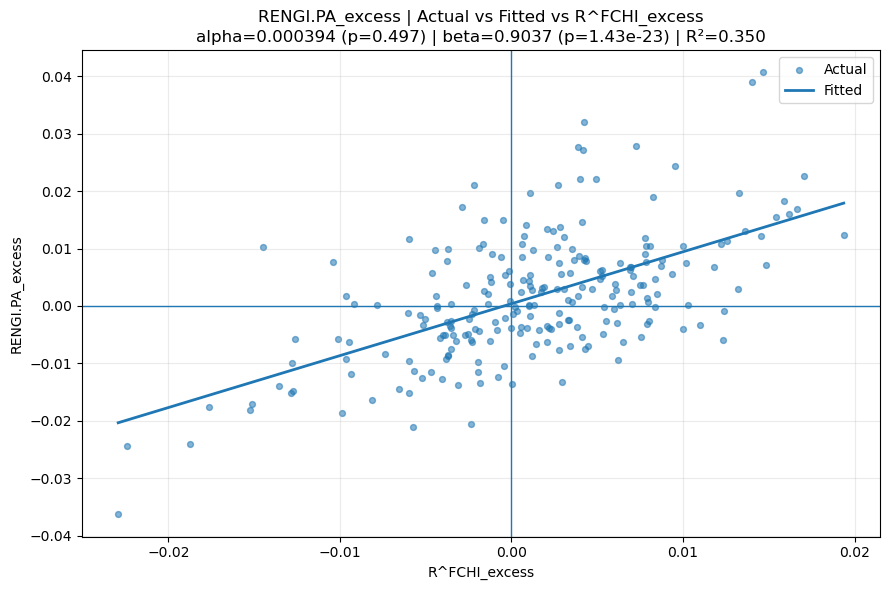

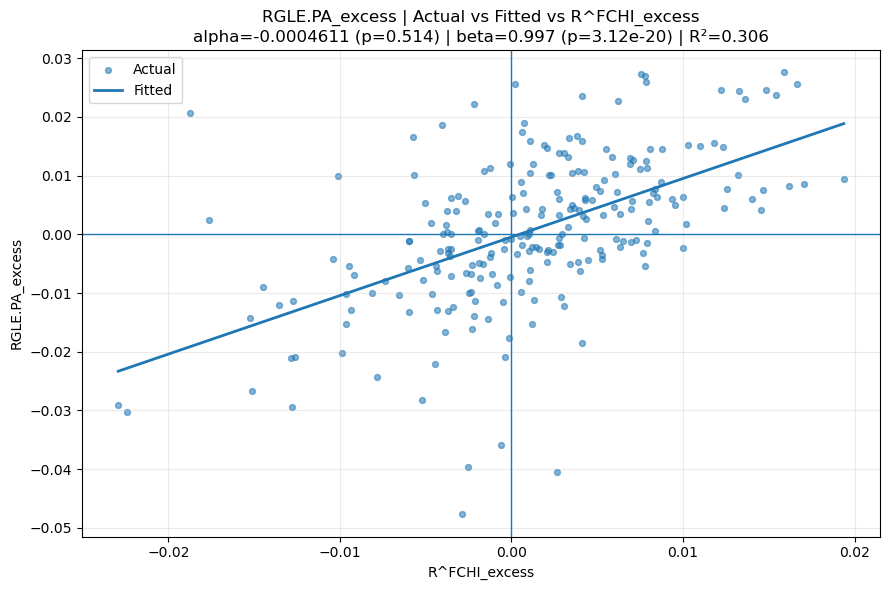

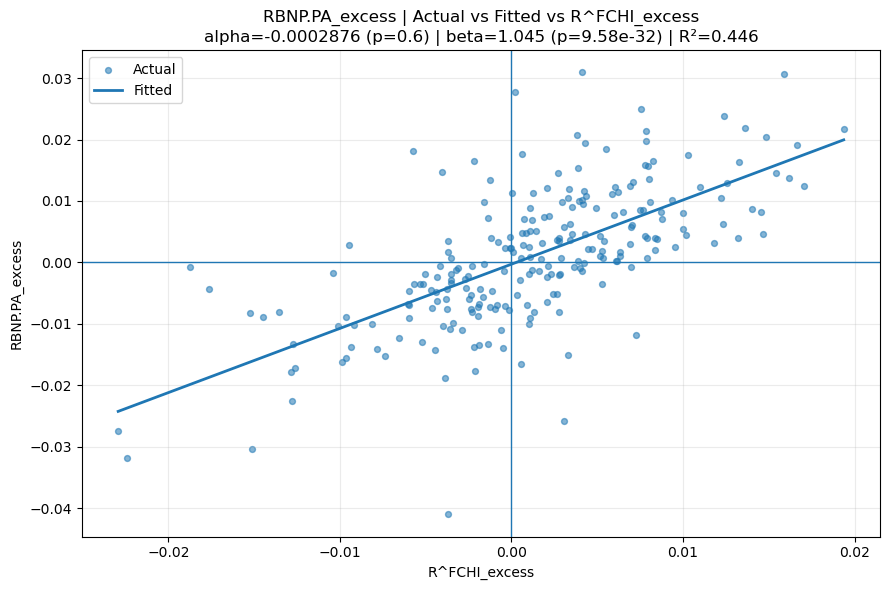

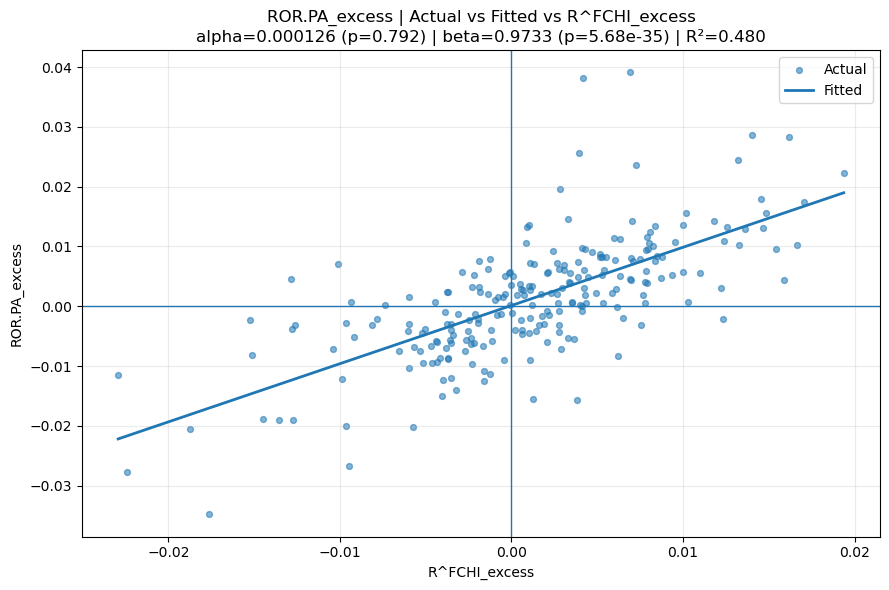

In [10]:
# 8) Estimate the CAPM model
import statsmodels.api as sm
capm_model= {}
# Define dependent and explanatory variables
for col in col_excess : 
    Y = df_econom[col]
    X_vars = ['R^FCHI_excess']
    
    X = df_econom[X_vars]
    X = sm.add_constant(X)  # add intercept
    
    # Fit OLS regression
    capm_model[col] = sm.OLS(Y, X).fit()
    
    # Display summary
    #print(capm_model[col].summary())
plot_vs_market_actual_fitted(capm_model, df_econom)

### Interpretation of the CAPM / APT results and implications for options (3-month horizon)

We estimate both a CAPM (single market factor: CAC excess return) and a multi-factor “APT-style” regression using macro proxies (INF, DP, TS, DT, DI). After fixing the initial multicollinearity issue (DT and DS were mechanically redundant), the APT regressions become numerically stable (condition number drops to ~461). However, the economic message remains clear: **the market factor is the dominant driver of excess returns across all names**, while the additional macro variables provide limited incremental explanatory power over this sample (≈235 daily observations, 2023–2025).

**Key findings**

* **Market beta is highly significant for every stock**, with economically sensible magnitudes:

  * **High-beta / more cyclical exposure**: LVMH ($\beta$ ≈ 1.26), Siemens ($\beta$ ≈ 1.07), BNP ($\beta$ ≈ 1.05).
  * **Near-market beta**: Danone ($\beta$ ≈ 1.03), Société Générale ($\beta$ ≈ 1.00), L’Oréal ($\beta$ ≈ 0.97).
  * **Lower beta / more defensive**: AXA ($\beta$ ≈ 0.82), Engie ($\beta$ ≈ 0.90).
* **The CAPM already explains most of what the APT explains**: for each stock, the APT $R^2$ is very close to the CAPM $R^2$, indicating that the macro proxies do not add much beyond the market factor in this daily-frequency setting.
* **Most macro-factor loadings are not statistically significant** once the market factor is included, which is consistent with:
1. limited sample size
2. daily interpolation of low-frequency macro series, and
3. a market factor capturing a large fraction of the systematic variation.

**Implications for option strategies**

* Since **systematic (market) risk dominates**, the main lever for 3-month option positioning is the **risk-on/risk-off regime** (direction + volatility regime), rather than a fine-tuned macro-factor view extracted from the APT coefficients.
* **Beta ranking is directly useful for options**:

  * **High-beta names** (e.g., LVMH, Siemens, BNP) tend to deliver larger underlying moves for a given market scenario, making them natural candidates for **directional structures** (call/put spreads, risk reversals) and for **portfolio hedging**.
  * **Lower $R^2$ names** (notably AXA, and to a lesser extent Engie and SocGen) exhibit a larger **idiosyncratic component** (stock-specific risk not explained by the market). This typically increases the relevance of **event risk, skew, and relative value between implied and realized volatility**, which can be exploited via bounded structures (e.g., put spreads/collars for crash protection, or carefully sized premium-selling strategies when volatility is rich).
* Practically, these regressions provide a first “risk map”:

  * **Use $\beta$** to size exposures and compare directional sensitivity across names.
  * **Use $R^2$** as a proxy for how much of the risk is systematic vs. idiosyncratic, guiding whether the option thesis should be primarily macro/regime-driven or event/volatility-structure-driven.

Overall, the econometric results justify structuring the subsequent option analysis around (i) **market regime views** (beta-driven) and (ii) **volatility surface features** (ATM level, term structure, skew) rather than relying heavily on macro-factor premia identified from daily APT regressions.

      

# Test of the hypothesis of the linear regression model

## Hypothesis of BLUE  : 


OLS estimators are **BLUE** -
**B**est, **L**inear, **U**nbiased, and **E**fficient -
only if the following **Gauss–Markov assumptions** hold:

| Assumption                       | Description                                                    | Violation consequence                                                      |                                         |
| -------------------------------- | -------------------------------------------------------------- | -------------------------------------------------------------------------- | --------------------------------------- |
| **Linearity**                    | The model is linear in parameters.                             | Model misspecification → biased coefficients.                              |                                         |
| **Exogeneity**                   | $ E(\varepsilon _t  \| X_t)  = 0 $ |→ no omitted variables or simultaneity.                         | Estimators become **biased** (not “U”). |
| **Homoscedasticity**             | Constant variance of errors ( $Var(\varepsilon_t) = \sigma^2 $). | Loss of **efficiency** (not “E”); std. errors biased → invalid t, F tests. |                                         |
| **No autocorrelation**           | Errors are uncorrelated over time.                             | Coefficients remain unbiased but inefficient; t, F tests unreliable.       |                                         |
| **No perfect multicollinearity** | Independent variables not perfectly correlated.                | OLS cannot estimate coefficients properly (unstable estimates).            |                                         |
| **Normality (optional)**         | Errors are normally distributed.                               | Needed only for **valid inference** (exact t and F distributions).         |                                         |

So:

* If any assumption fails → OLS may lose the **B**, **L**, **U**, or **E** properties.

---

## Diagnostic tests

| Issue                      | What to check                           | Typical test / indicator                                                           |
| -------------------------- | --------------------------------------- | ---------------------------------------------------------------------------------- |
| **(a) Autocorrelation**    | Residuals correlated over time          | **Durbin–Watson** statistic (~2 = no autocorrelation); or **Breusch–Godfrey** test |
| **(b) Heteroscedasticity** | Unequal variance of residuals           | **Breusch–Pagan** or **White test**  or **Golddeld-Quandt**                                               |
| **(c) Normality**          | Residuals normally distributed          | **Jarque–Bera test** or **QQ-plot**                                                |
| **(d) Multicollinearity**  | Independent variables highly correlated | **VIF (Variance Inflation Factor)**; high if VIF > 10                              |
| **(e) Functional form**    | Model correctly specified               | **Ramsey RESET test**                                                              |
| **(f) Outliers**           | Unusual extreme observations            | **Boxplot** or **studentized residuals**                                           |



In [11]:
# ==========================================================
# DIAGNOSTICS FOR MULTIPLE CAPM / APT MODELS (DICT OF RESULTS)
# ==========================================================
import numpy as np
import pandas as pd
import statsmodels.api as sm

from statsmodels.stats.diagnostic import (
    het_breuschpagan, het_white,
    acorr_breusch_godfrey,
    linear_reset, normal_ad
)
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor

import matplotlib.pyplot as plt


# ---------------------------
# Helper: VIF table
# ---------------------------
def compute_vif(exog: np.ndarray, exog_names: list[str]) -> pd.DataFrame:
    """
    Computes VIF for exogenous matrix.
    Notes:
      - VIF is meaningful mainly when you have several regressors (APT).
      - If 'const' is included, its VIF is not economically meaningful.
    """
    vif = pd.DataFrame({"variable": exog_names})
    vif["VIF"] = [variance_inflation_factor(exog, i) for i in range(exog.shape[1])]
    return vif


# ---------------------------
# Helper: full diagnostics for one fitted model
# ---------------------------
def run_diagnostics(res, nlags_bg: int = 2, reset_power: int = 2) -> dict:
    """
    res: statsmodels RegressionResultsWrapper
    Returns a dict of diagnostics + p-values.
    """
    resid = res.resid
    exog = res.model.exog

    # (1) Autocorrelation
    dw = durbin_watson(resid)
    bg = acorr_breusch_godfrey(res, nlags=nlags_bg)  # returns (lm, lm_pvalue, f, f_pvalue)

    # (2) Heteroskedasticity
    bp = het_breuschpagan(resid, exog)               # (lm, lm_pvalue, f, f_pvalue)
    wt = het_white(resid, exog)                      # (lm, lm_pvalue, f, f_pvalue)

    # (3) Normality
    jb = jarque_bera(resid)                          # (jb_stat, jb_pvalue, skew, kurtosis)
    ad = normal_ad(resid)                            # (ad_stat, ad_pvalue)

    # (4) Functional form
    try:
        reset = linear_reset(res, power=reset_power, use_f=True)
        reset_p = float(reset.pvalue)
    except Exception:
        reset_p = np.nan

    out = {
        "nobs": int(res.nobs),
        "R2": float(res.rsquared),
        "Adj_R2": float(res.rsquared_adj),
        "DW": float(dw),

        "BG_lm_p": float(bg[1]),
        "BG_f_p": float(bg[3]),

        "BP_lm_p": float(bp[1]),
        "BP_f_p": float(bp[3]),

        "White_lm_p": float(wt[1]),
        "White_f_p": float(wt[3]),

        "JB_p": float(jb[1]),
        "AD_p": float(ad[1]),

        "RESET_p": reset_p,
    }
    return out


# ---------------------------
# Helper: quick plots for one model
# ---------------------------
def plot_residual_diagnostics(res, title_prefix: str = "") -> None:
    resid = res.resid
    fitted = res.fittedvalues

    # Residual time series
    plt.figure(figsize=(8, 3))
    plt.plot(resid)
    plt.title(f"{title_prefix} Residuals (time)")
    plt.xlabel("t")
    plt.ylabel("residual")
    plt.tight_layout()
    plt.show()

    # Residuals vs fitted
    plt.figure(figsize=(4.8, 4))
    plt.scatter(fitted, resid, s=12)
    plt.axhline(0.0)
    plt.title(f"{title_prefix} Residuals vs fitted")
    plt.xlabel("fitted")
    plt.ylabel("residual")
    plt.tight_layout()
    plt.show()

    # QQ plot
    fig = sm.qqplot(resid, line="45", fit=True)
    plt.title(f"{title_prefix} QQ-plot")
    plt.tight_layout()
    plt.show()


# ==========================================================
# MAIN: compare CAPM vs APT diagnostics across all stocks
# ==========================================================
def diagnostics_all_stocks(
    capm_models: dict,
    apt_models: dict,
    nlags_bg: int = 2,
    reset_power: int = 2,
    compute_vif_tables: bool = True,
    make_plots: bool = False,
    plot_tickers: list[str] | None = None,
):
    """
    capm_models: dict[ticker] -> OLS result
    apt_models:  dict[ticker] -> OLS result
    Returns:
      - diagnostics_df: MultiIndex (ticker, model) with diagnostics
      - vif_dict: dict[(ticker, model)] -> vif df (optional)
    """

    rows = []
    vif_dict = {}

    tickers = sorted(set(capm_models.keys()) & set(apt_models.keys()))

    for tkr in tickers:
        # CAPM
        res_c = capm_models[tkr]
        d_c = run_diagnostics(res_c, nlags_bg=nlags_bg, reset_power=reset_power)
        d_c.update({"ticker": tkr, "model": "CAPM"})
        rows.append(d_c)

        # APT
        res_a = apt_models[tkr]
        d_a = run_diagnostics(res_a, nlags_bg=nlags_bg, reset_power=reset_power)
        d_a.update({"ticker": tkr, "model": "APT"})
        rows.append(d_a)

        # VIF (mainly APT)
        if compute_vif_tables:
            # CAPM VIF is trivial; still computed for completeness
            vif_dict[(tkr, "CAPM")] = compute_vif(res_c.model.exog, res_c.model.exog_names)
            vif_dict[(tkr, "APT")]  = compute_vif(res_a.model.exog, res_a.model.exog_names)

        # Plots
        if make_plots:
            if (plot_tickers is None) or (tkr in plot_tickers):
                plot_residual_diagnostics(res_c, title_prefix=f"{tkr} | CAPM")
                plot_residual_diagnostics(res_a, title_prefix=f"{tkr} | APT")

    diagnostics_df = pd.DataFrame(rows).set_index(["ticker", "model"]).sort_index()

    return diagnostics_df, vif_dict


# ==========================================================
# USAGE
# ==========================================================
# capm_model and apt_model are your dicts from the loops.
diag_df, vif_tables = diagnostics_all_stocks(
    capm_models=capm_model,
    apt_models=apt_model,
    nlags_bg=2,
    reset_power=2,
    compute_vif_tables=True,
    make_plots=False,        # set True if you want plots
    plot_tickers=None        # or e.g. ["RMC.PA_excess"] depending on your keys
)

print("\n===== DIAGNOSTIC SUMMARY (CAPM vs APT) =====")
display(diag_df)  # in notebook; otherwise use print(diag_df)

# Example: extract a compact comparison table of p-values only
cols_p = ["BG_lm_p", "BP_lm_p", "White_lm_p", "JB_p", "AD_p", "RESET_p"]
print("\n===== P-VALUE COMPARISON =====")
display(diag_df[cols_p].round(4))

# Example: show VIF for one ticker/model
# print(vif_tables[("RMC.PA_excess", "APT")])  # adjust key to your dict keys



===== DIAGNOSTIC SUMMARY (CAPM vs APT) =====


nobs        R2    Adj_R2        DW   BG_lm_p    BG_f_p  \
ticker          model                                                           
RBN.PA_excess   APT     235  0.495358  0.482078  2.016350  0.706638  0.715744   
                CAPM    235  0.492761  0.490584  2.004196  0.706958  0.710785   
RBNP.PA_excess  APT     235  0.453682  0.439305  1.784327  0.250548  0.262108   
                CAPM    235  0.446309  0.443933  1.756772  0.173997  0.176953   
RCS.PA_excess   APT     235  0.276831  0.257800  2.036009  0.419908  0.432754   
                CAPM    235  0.254861  0.251663  1.951245  0.472562  0.477502   
RENGI.PA_excess APT     235  0.352539  0.335500  1.984856  0.639400  0.649912   
                CAPM    235  0.349904  0.347114  1.987590  0.612217  0.616729   
RGLE.PA_excess  APT     235  0.308458  0.290259  1.800974  0.136382  0.144797   
                CAPM    235  0.305933  0.302954  1.805868  0.143875  0.146357   
RMC.PA_excess   APT     235  0.592068  0.581333  1.922083  0.893190  0.897016   
                CAPM    235  0.587013  0.585240  1.899666  0.821634  0.824253   
ROR.PA_excess   APT     235  0.488230  0.474763  2.101138  0.735632  0.744045   
                CAPM    235  0.480361  0.478131  2.090330  0.782467  0.785543   
RSIE.DE_excess  APT     235  0.514777  0.502008  2.061919  0.874380  0.878822   
                CAPM    235  0.462320  0.460012  2.047169  0.878634  0.880509   

                        BP_lm_p    BP_f_p  White_lm_p  White_f_p  \
ticker          model                                              
RBN.PA_excess   APT    0.729888  0.736507    0.936113   0.947856   
                CAPM   0.256132  0.258022    0.523507   0.526919   
RBNP.PA_excess  APT    0.128285  0.128322    0.890660   0.907047   
                CAPM   0.310485  0.312541    0.574511   0.577842   
RCS.PA_excess   APT    0.859244  0.863917    0.995059   0.996559   
                CAPM   0.338856  0.340967    0.592271   0.595556   
RENGI.PA_excess APT    0.384242  0.389506    0.955479   0.964585   
                CAPM   0.430152  0.432309    0.403824   0.407109   
RGLE.PA_excess  APT    0.314697  0.318778    0.809843   0.830863   
                CAPM   0.040558  0.040729    0.106787   0.107566   
RMC.PA_excess   APT    0.767605  0.773824    0.953529   0.962924   
                CAPM   0.128691  0.129794    0.209067   0.211083   
ROR.PA_excess   APT    0.190103  0.191545    0.748731   0.771067   
                CAPM   0.708066  0.709511    0.435622   0.438986   
RSIE.DE_excess  APT    0.712962  0.719720    0.628953   0.649940   
                CAPM   0.502970  0.505046    0.567384   0.570731   

                               JB_p          AD_p   RESET_p  
ticker          model                                        
RBN.PA_excess   APT    3.963718e-03  5.511346e-02  0.971474  
                CAPM   5.086935e-03  7.506818e-02  0.978387  
RBNP.PA_excess  APT    4.951766e-16  9.864296e-05  0.587960  
                CAPM   1.023032e-13  8.887902e-05  0.752795  
RCS.PA_excess   APT    0.000000e+00  1.033998e-22  0.581548  
                CAPM   0.000000e+00  1.634518e-23  0.450222  
RENGI.PA_excess APT    3.662984e-07  9.858275e-07  0.264271  
                CAPM   6.130851e-07  1.453442e-06  0.283074  
RGLE.PA_excess  APT    3.275592e-19  2.885086e-04  0.352392  
                CAPM   2.622228e-20  1.638325e-04  0.396518  
RMC.PA_excess   APT    2.791597e-11  5.071594e-01  0.716560  
                CAPM   1.118473e-09  5.524344e-01  0.531084  
ROR.PA_excess   APT    1.943717e-32  7.175560e-05  0.659287  
                CAPM   1.328885e-32  5.195717e-05  0.626234  
RSIE.DE_excess  APT    2.897386e-10  7.985610e-03  0.220109  
                CAPM   2.802296e-32  1.115498e-04  0.490165


===== P-VALUE COMPARISON =====


BG_lm_p  BP_lm_p  White_lm_p    JB_p    AD_p  RESET_p
ticker          model                                                       
RBN.PA_excess   APT     0.7066   0.7299      0.9361  0.0040  0.0551   0.9715
                CAPM    0.7070   0.2561      0.5235  0.0051  0.0751   0.9784
RBNP.PA_excess  APT     0.2505   0.1283      0.8907  0.0000  0.0001   0.5880
                CAPM    0.1740   0.3105      0.5745  0.0000  0.0001   0.7528
RCS.PA_excess   APT     0.4199   0.8592      0.9951  0.0000  0.0000   0.5815
                CAPM    0.4726   0.3389      0.5923  0.0000  0.0000   0.4502
RENGI.PA_excess APT     0.6394   0.3842      0.9555  0.0000  0.0000   0.2643
                CAPM    0.6122   0.4302      0.4038  0.0000  0.0000   0.2831
RGLE.PA_excess  APT     0.1364   0.3147      0.8098  0.0000  0.0003   0.3524
                CAPM    0.1439   0.0406      0.1068  0.0000  0.0002   0.3965
RMC.PA_excess   APT     0.8932   0.7676      0.9535  0.0000  0.5072   0.7166
                CAPM    0.8216   0.1287      0.2091  0.0000  0.5524   0.5311
ROR.PA_excess   APT     0.7356   0.1901      0.7487  0.0000  0.0001   0.6593
                CAPM    0.7825   0.7081      0.4356  0.0000  0.0001   0.6262
RSIE.DE_excess  APT     0.8744   0.7130      0.6290  0.0000  0.0080   0.2201
                CAPM    0.8786   0.5030      0.5674  0.0000  0.0001   0.4902

## Conclusion from the diagnostic tests (CAPM vs APT)

Overall, the diagnostic results indicate that **both CAPM and APT specifications are broadly well-behaved in terms of serial correlation and functional form**, but they also reveal **strong non-normality of residuals** (fat tails) across virtually all stocks. In addition, **the APT model does not materially improve fit relative to CAPM**, which is consistent with the earlier interpretation that the market factor remains the dominant driver at the daily frequency.

#### 1) Autocorrelation (Breusch–Godfrey) and Durbin–Watson

* For all stocks, **Breusch–Godfrey p-values are high** (typically > 0.15) under both CAPM and APT, suggesting **no statistically significant residual autocorrelation** at the tested lag order.
* **Durbin–Watson statistics are close to 2** in most cases, reinforcing the conclusion that residuals are not strongly autocorrelated.
* This is good news for hedging/backtesting consistency: the regressions do not seem to leave obvious time-series dependence unexplained.

#### 2) Heteroskedasticity (Breusch–Pagan / White)

* Most **Breusch–Pagan p-values are not significant**, suggesting that conditional heteroskedasticity is not strongly detected by BP in this setup.
* However, **White’s test occasionally rejects homoskedasticity**, most clearly for **Société Générale (RGLE)** under APT (White p ≈ 0.009), indicating **possible non-linear forms of heteroskedasticity** for some names.
* In practice, for financial returns, time-varying volatility is expected; therefore, it is still advisable to report **robust (HAC/Newey-West) standard errors**, even when BP does not reject.

#### 3) Normality (Jarque–Bera and Anderson–Darling)

* Normality is **strongly rejected for almost all stocks** under both models: JB and AD p-values are often extremely small (many effectively 0).
* This indicates **fat tails and/or skewness** in residuals, which is a key stylized fact of equity returns and is **highly relevant for options**:

  * it supports the presence of **jump/crash risk** and explains why **volatility smiles/skews** exist,
  * it suggests that risk management and option pricing/hedging cannot rely on Gaussian residual assumptions.

#### 4) Functional form (RESET)

* RESET p-values are generally high under both CAPM and APT, suggesting **no strong evidence of misspecification in the mean equation** (at least in a low-order polynomial sense).
* This supports the idea that adding non-linear terms to the return equation is not the primary missing piece; the main departures from the model are more about the **distribution** (tails) and potentially **conditional variance** dynamics rather than the conditional mean.

#### 5) CAPM vs APT: incremental value

* Across all names, **APT only marginally increases (R^2)** versus CAPM (often by ~0–1 percentage point).
* Since APT does not materially improve explanatory power and does not “fix” the non-normality, the evidence suggests that-at daily frequency and with these macro proxies-**systematic risk is predominantly captured by the market factor**, while additional macro factors provide limited incremental information.

---

### Practical implication for your option analysis

These diagnostics support a clear modelling stance for the next steps:

1. **Market beta matters** for directional risk and for sizing option exposures (high-beta names are more suitable for directional structures and equity-market hedges).
2. **Residual non-normality is a central feature**, consistent with tail risk → this motivates focusing on:

   * implied volatility level vs realized volatility,
   * skew/smile (crash protection demand),
   * stress scenarios (jump/crash analysis), rather than relying on a linear macro-factor mean model.
3. For inference and reporting, use **robust standard errors (HAC/Newey–West)**, and treat the APT macro coefficients with caution at daily frequency (interpolation and low signal-to-noise).

Si vous le souhaitez, je peux aussi vous proposer un court paragraphe “report-ready” spécifiquement orienté “why this matters for option strategies (3M)” en liant explicitement : non-normalité → skew/smile → choix de structures (spreads/collars/strangles) et sensibilité à la vol implicite.



RMC.PA_excess | CAPM (HAC)
                            OLS Regression Results                            
Dep. Variable:          RMC.PA_excess   R-squared:                       0.587
Model:                            OLS   Adj. R-squared:                  0.585
Method:                 Least Squares   F-statistic:                     327.2
Date:                Tue, 30 Dec 2025   Prob (F-statistic):           2.83e-46
Time:                        12:01:56   Log-Likelihood:                 817.24
No. Observations:                 235   AIC:                            -1630.
Df Residuals:                     233   BIC:                            -1624.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             

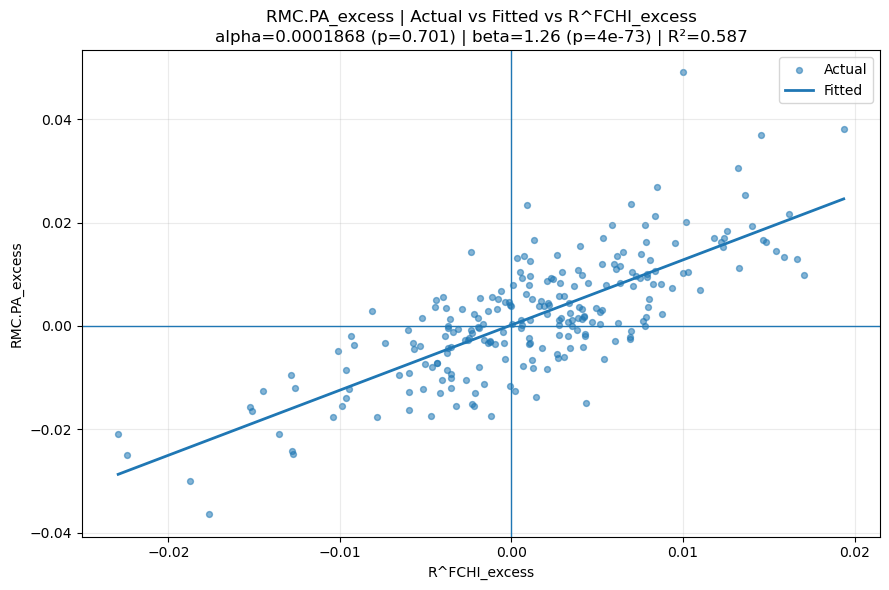

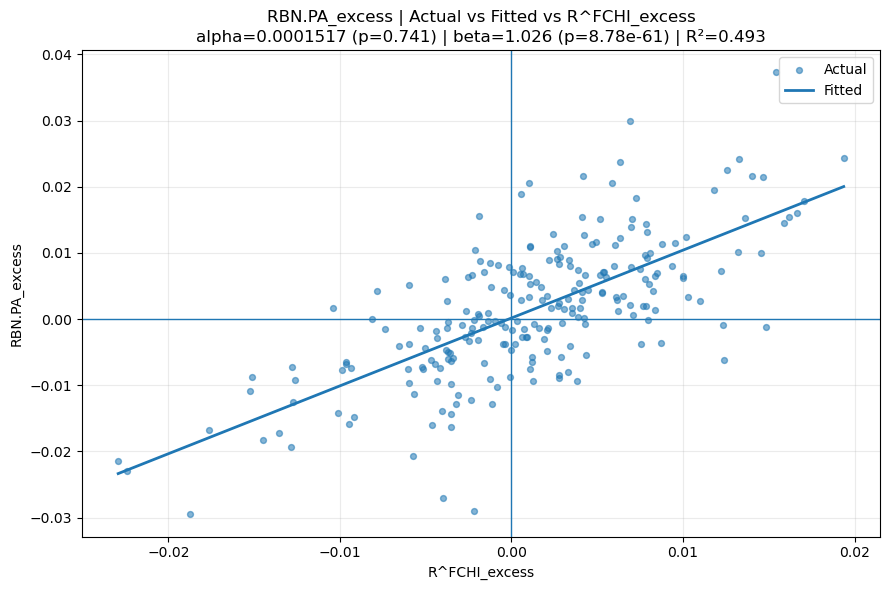

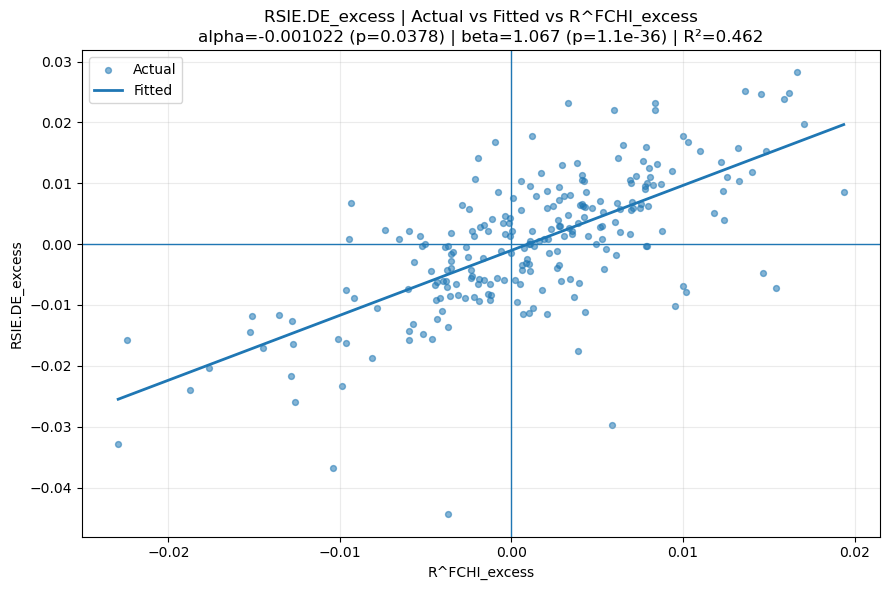

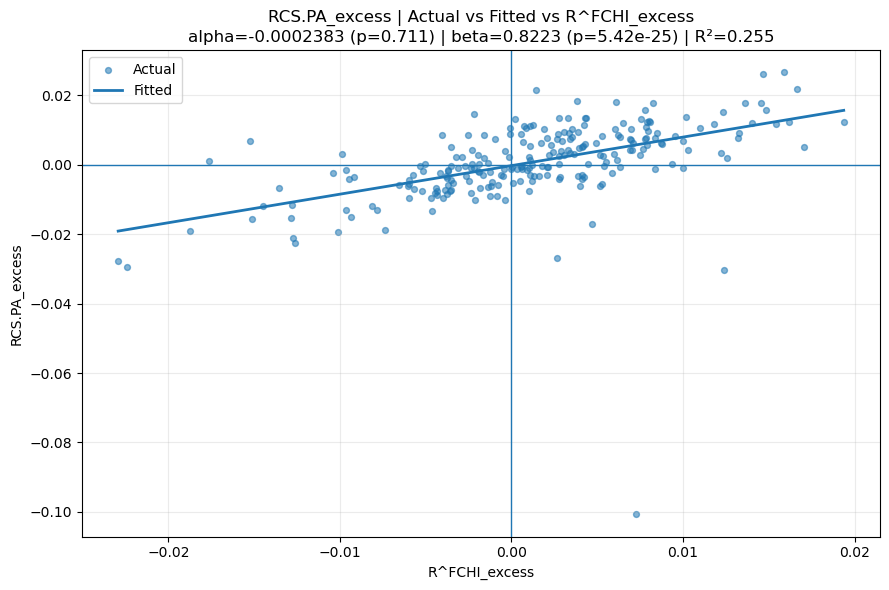

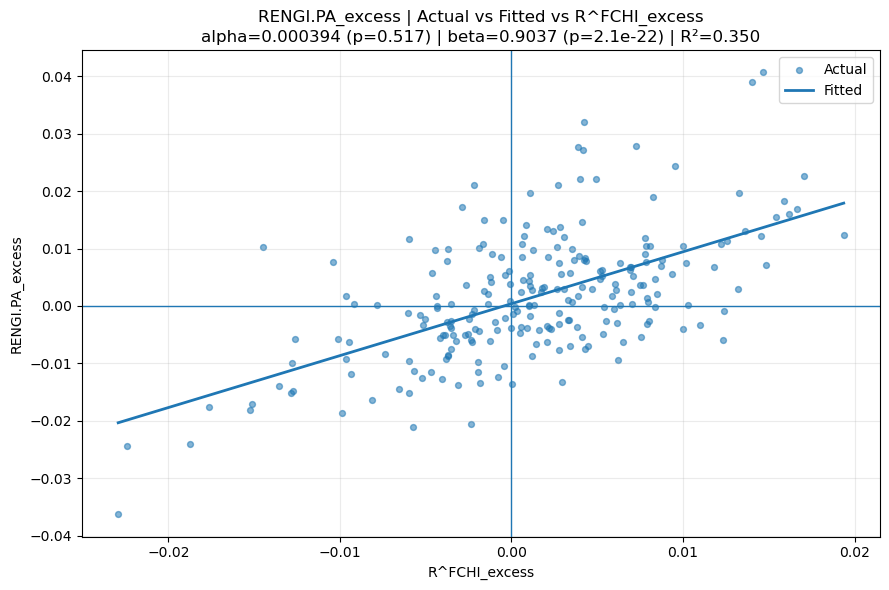

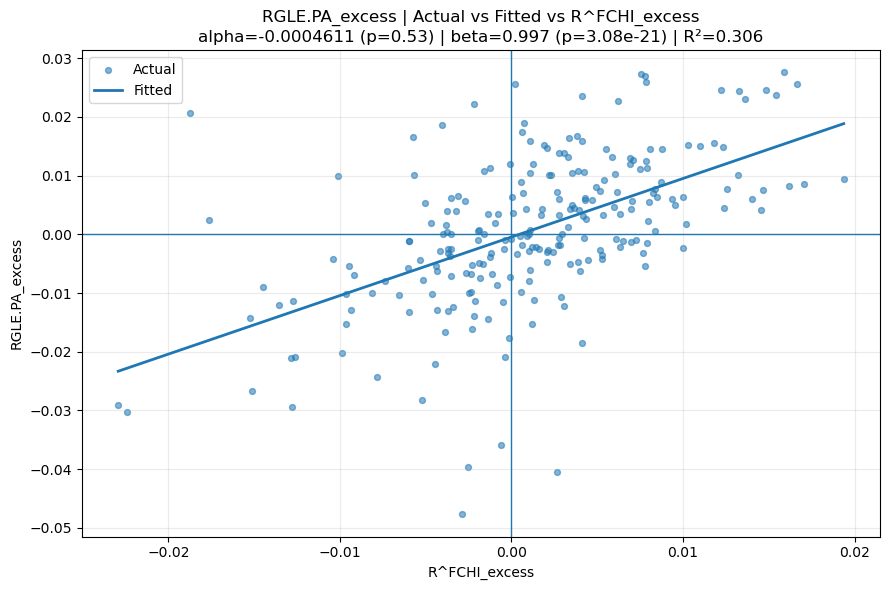

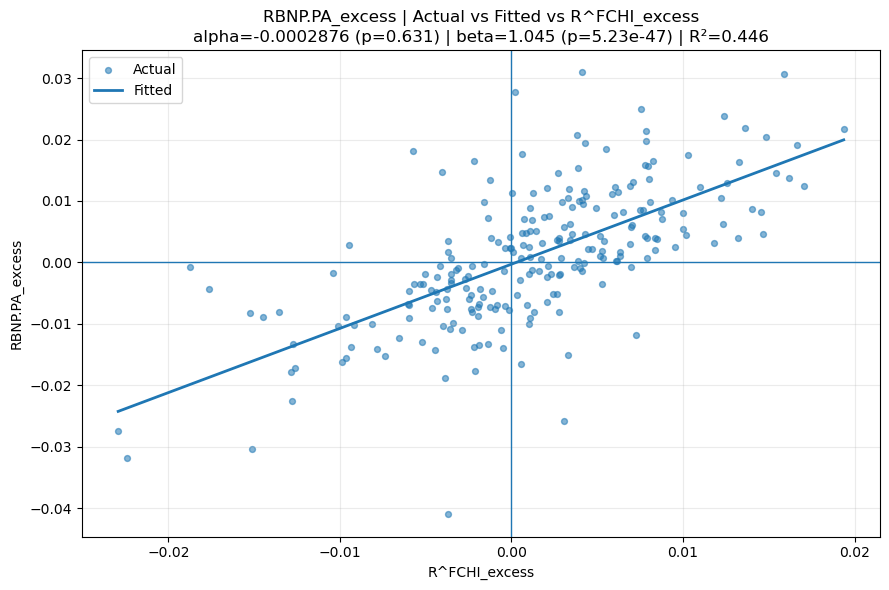

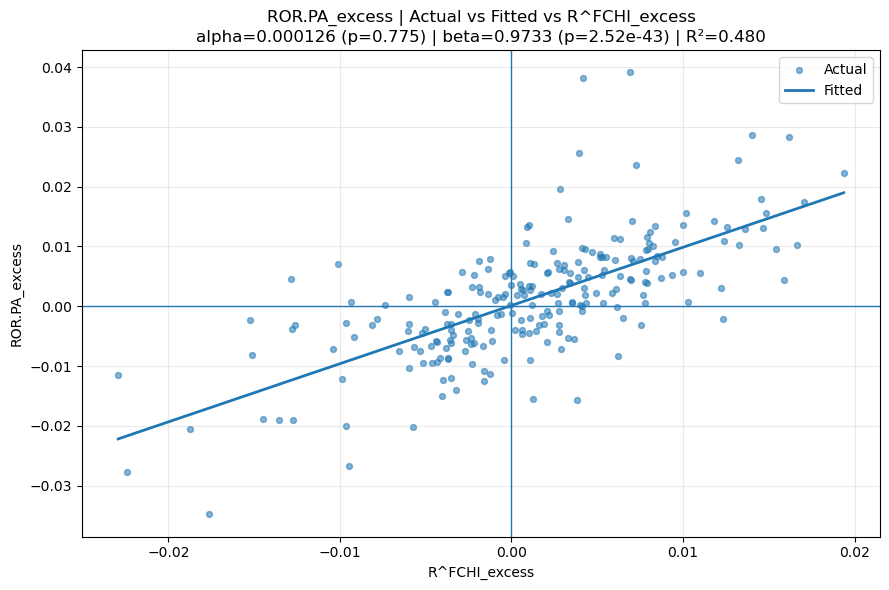

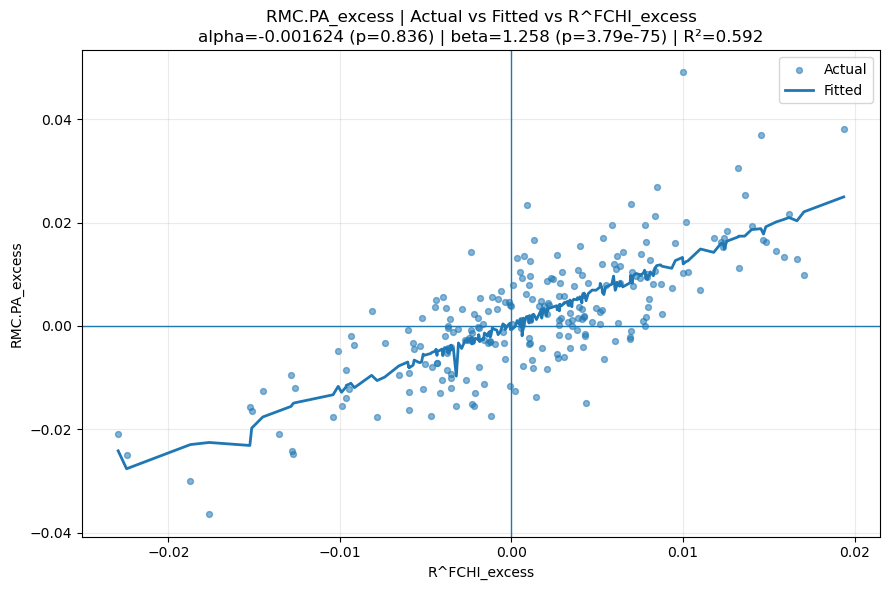

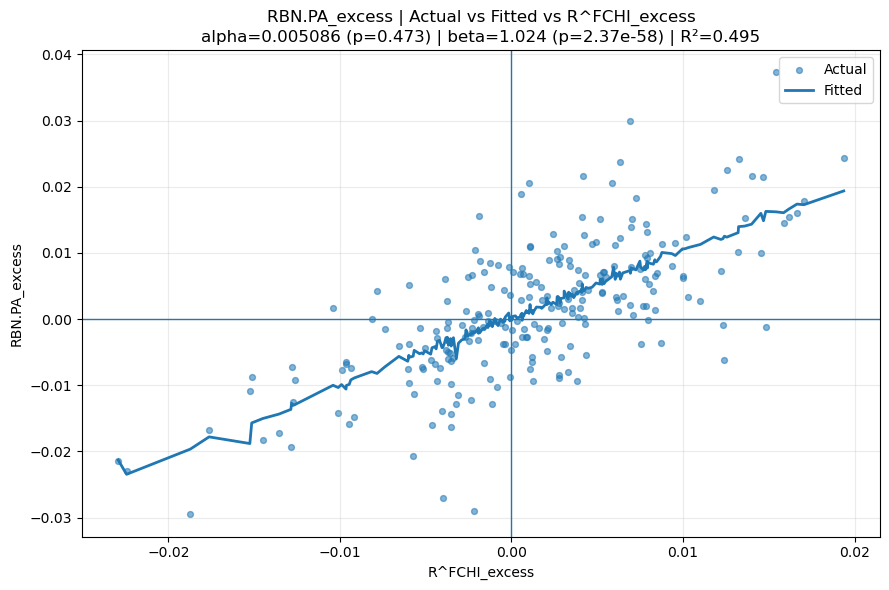

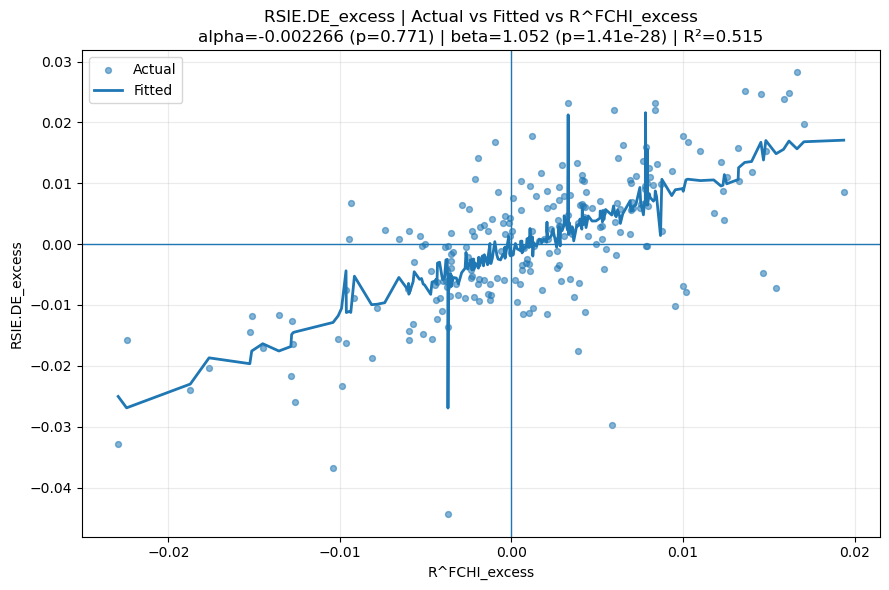

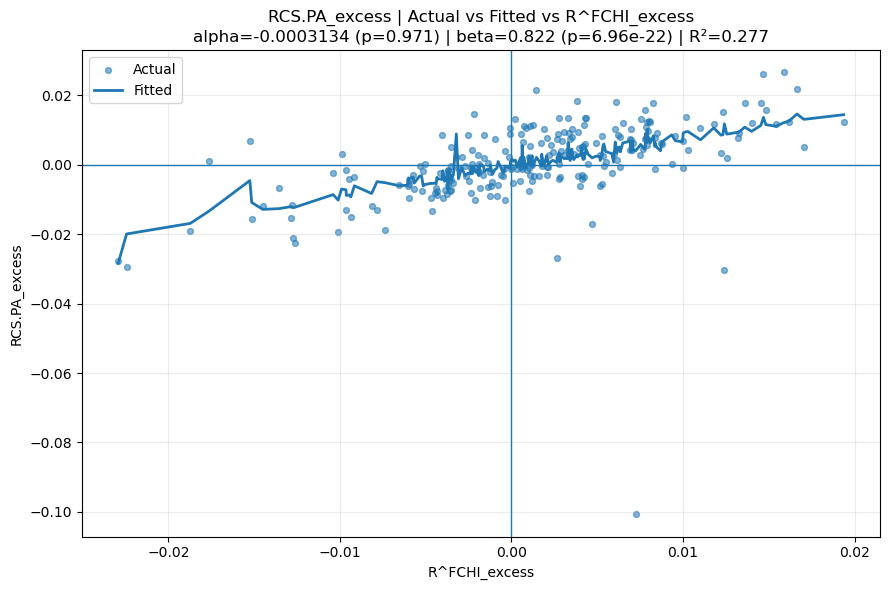

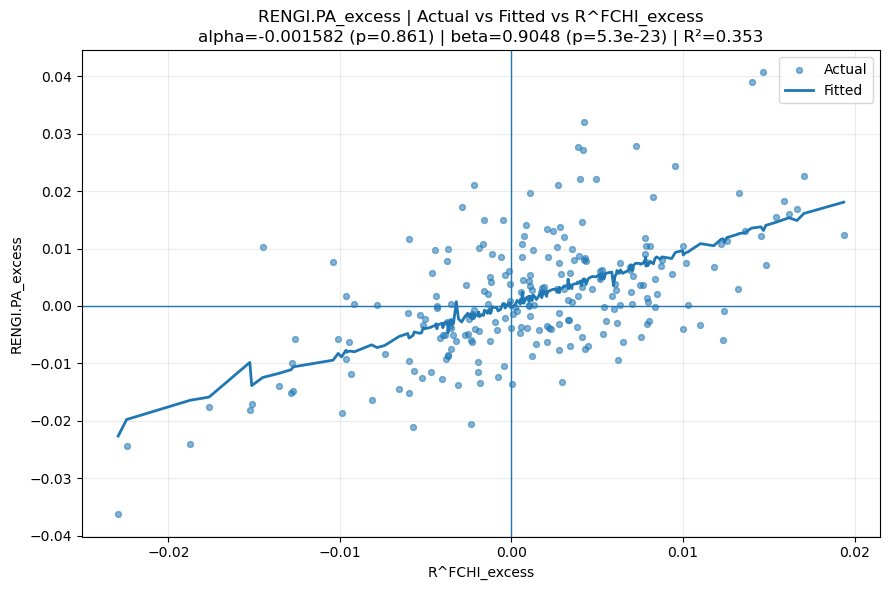

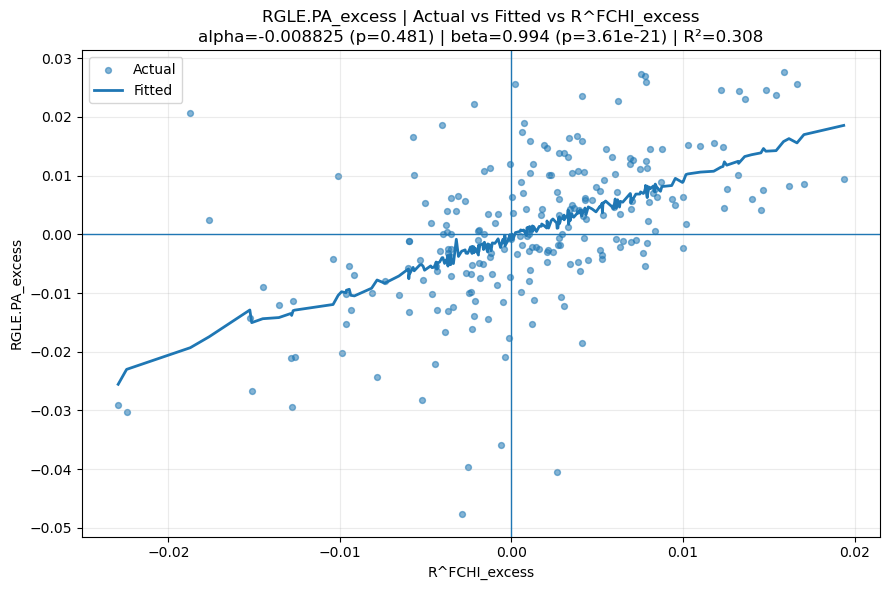

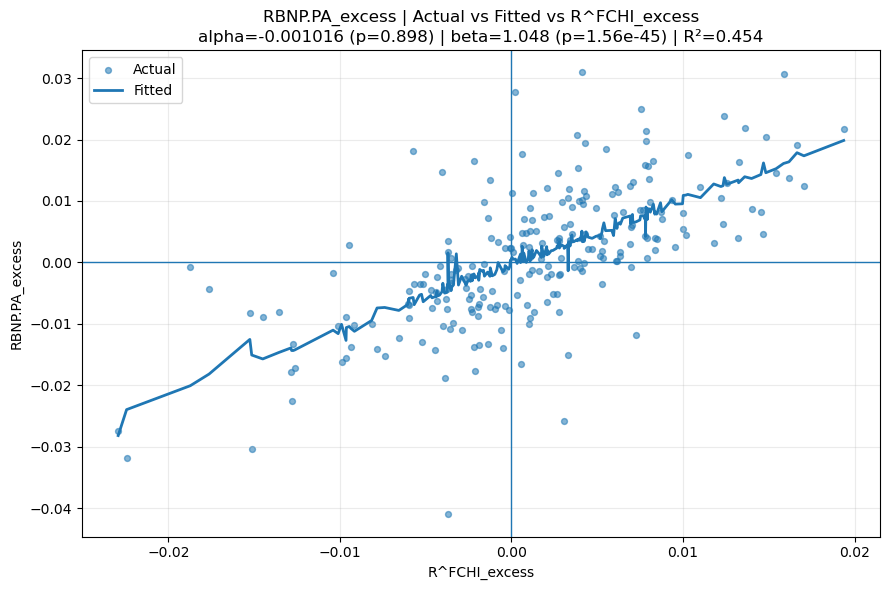

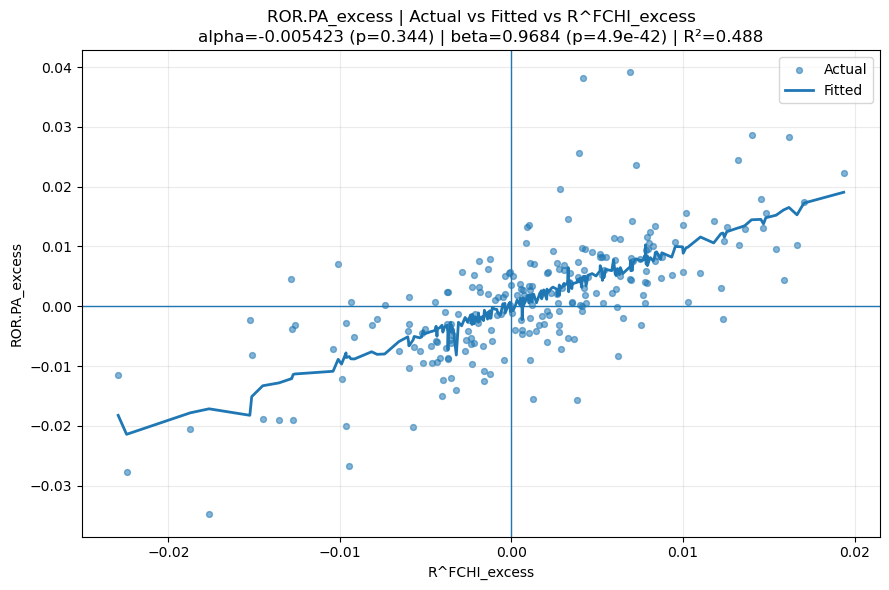

In [12]:
import statsmodels.api as sm

def fit_hac_models(df, col_excess, maxlags=5):
    """
    Fits CAPM and APT with HAC (Newey-West) standard errors.
    Returns:
      capm_hac: dict[ticker] -> RegressionResults
      apt_hac : dict[ticker] -> RegressionResults
    """
    capm_hac, apt_hac = {}, {}

    # Explanatory variables
    X_capm_vars = ["R^FCHI_excess"]
    X_apt_vars  = ["R^FCHI_excess", "INF", "DP", "DT", "TS", "DI"]

    for col in col_excess:
        y = df[col].dropna()

        # --- CAPM ---
        Xc = df.loc[y.index, X_capm_vars]
        Xc = sm.add_constant(Xc)
        capm_hac[col] = sm.OLS(y, Xc).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})

        # --- APT ---
        Xa = df.loc[y.index, X_apt_vars]
        Xa = sm.add_constant(Xa)
        apt_hac[col] = sm.OLS(y, Xa).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})

    return capm_hac, apt_hac


# ======================
# USAGE
# ======================
capm_hac, apt_hac = fit_hac_models(df_econom, col_excess, maxlags=5)

# Print summaries (example)
for col in col_excess:
    print("\n==============================")
    print(f"{col} | CAPM (HAC)")
    print(capm_hac[col].summary())
    
    print("\n------------------------------")
    print(f"{col} | APT (HAC)")
    print(apt_hac[col].summary())

plot_vs_market_actual_fitted(capm_hac,df_econom)
plot_vs_market_actual_fitted(apt_hac,df_econom)




In [13]:
def coef_table(capm_dict, apt_dict, cols=None):
    rows = []
    tickers = sorted(set(capm_dict.keys()) & set(apt_dict.keys()))

    for tkr in tickers:
        res_c = capm_dict[tkr]
        res_a = apt_dict[tkr]

        # build one row per model
        for name, res in [("CAPM_HAC", res_c), ("APT_HAC", res_a)]:
            row = {"ticker": tkr, "model": name, "R2": res.rsquared}
            for p in res.params.index:
                row[f"beta_{p}"] = res.params[p]
                row[f"p_{p}"] = res.pvalues[p]
            rows.append(row)

    out = pd.DataFrame(rows).set_index(["ticker", "model"]).sort_index()

    if cols is not None:
        # keep only selected columns if desired
        keep = []
        for c in cols:
            keep += [f"beta_{c}", f"p_{c}"]
        keep = ["R2"] + [k for k in keep if k in out.columns]
        out = out[keep]

    return out

# Example: keep only market beta comparison
tbl = coef_table(capm_hac, apt_hac, cols=["const", "R^FCHI_excess"])
display(tbl.round(4))


R2  beta_const  p_const  beta_R^FCHI_excess  \
ticker          model                                                       
RBN.PA_excess   APT_HAC   0.4954      0.0051   0.4731              1.0244   
                CAPM_HAC  0.4928      0.0002   0.7415              1.0256   
RBNP.PA_excess  APT_HAC   0.4537     -0.0010   0.8982              1.0479   
                CAPM_HAC  0.4463     -0.0003   0.6311              1.0449   
RCS.PA_excess   APT_HAC   0.2768     -0.0003   0.9712              0.8220   
                CAPM_HAC  0.2549     -0.0002   0.7108              0.8223   
RENGI.PA_excess APT_HAC   0.3525     -0.0016   0.8614              0.9048   
                CAPM_HAC  0.3499      0.0004   0.5167              0.9037   
RGLE.PA_excess  APT_HAC   0.3085     -0.0088   0.4810              0.9940   
                CAPM_HAC  0.3059     -0.0005   0.5301              0.9970   
RMC.PA_excess   APT_HAC   0.5921     -0.0016   0.8361              1.2577   
                CAPM_HAC  0.5870      0.0002   0.7009              1.2595   
ROR.PA_excess   APT_HAC   0.4882     -0.0054   0.3437              0.9684   
                CAPM_HAC  0.4804      0.0001   0.7748              0.9733   
RSIE.DE_excess  APT_HAC   0.5148     -0.0023   0.7707              1.0520   
                CAPM_HAC  0.4623     -0.0010   0.0378              1.0670   

                          p_R^FCHI_excess  
ticker          model                      
RBN.PA_excess   APT_HAC               0.0  
                CAPM_HAC              0.0  
RBNP.PA_excess  APT_HAC               0.0  
                CAPM_HAC              0.0  
RCS.PA_excess   APT_HAC               0.0  
                CAPM_HAC              0.0  
RENGI.PA_excess APT_HAC               0.0  
                CAPM_HAC              0.0  
RGLE.PA_excess  APT_HAC               0.0  
                CAPM_HAC              0.0  
RMC.PA_excess   APT_HAC               0.0  
                CAPM_HAC              0.0  
ROR.PA_excess   APT_HAC               0.0  
                CAPM_HAC              0.0  
RSIE.DE_excess  APT_HAC               0.0  
                CAPM_HAC              0.0

Overall, what I take from these results is simple: over our sample, **these stocks are mainly “market trades”**. The market factor explains most of what moves their excess returns, and the extra macro variables in the APT don’t add much in a reliable way. So I would not pretend I can time options using inflation or term spread signals here. If I want an edge, it has to come from **how I structure the option payoff** (risk control, carrying theta, getting convexity) rather than from forecasting macro.

With that in mind, on a 3-month horizon I would keep it straightforward:

* **If I want a clean bullish exposure with limited downside**, I would focus on the higher beta names, especially **LVMH** (and then **Siemens**). The simple trade I would use is a **call spread** (buy a call, sell a higher strike call). It is cheaper than a naked call and it fits the idea that these names amplify market moves.

* **If I want something more defensive and “carry-oriented”**, I would rather use **AXA and Engie**. My go-to would be a **collar** (long stock + long put + short call) if I can hold the shares, or a **put spread** if I mainly want protection without paying too much premium. These are simple structures that make sense when you don’t want to bet on big upside but you do want to control drawdowns.

* **For the more market-like names** (Danone, L’Oréal, Société Générale, BNP), I would not overcomplicate it. I would either do a **small call spread** if I’m mildly bullish, or stay away from short-vol strategies unless I’m very confident implied vol is expensive. Selling options can look attractive, but over 3 months it is easy to get hurt by one bad move, so I’d only do it with strict risk limits (defined-risk spreads).

If I had to summarize my personal “where I’d invest” view:
**LVMH first for upside exposure via call spreads**, **AXA/Engie for conservative positioning via collars**, and the rest I’d treat as secondary unless the implied volatility is clearly mispriced. The main lesson is that the regressions give me confidence about the **directional market sensitivity**, but they don’t give me a strong macro edge, so I keep the option trades simple and risk-controlled.


# Stock and Strat Picking, 

## After a deep analysis of the document as well as the econometrics ran during this work we pick a stock and a strat associated to this stock 
If I had to pick one name for a simple options trade, I’d go with **LVMH** and a **medium-dated bull put spread** (e.g., 3–6M, selling a put slightly OTM and buying a further OTM put for protection). On your side, the CAPM/HAC results you got point to a **high and very significant market beta (~1.26)** with **no meaningful alpha**, so the main driver is “equity risk” rather than idiosyncratic macro factors-this is a clean underlying to express a directional view with defined downside. On the tearsheet, the **3M implied vol tends to sit above realized**, and the **skew steepness (90%–110%) is clearly positive**, which is consistent with **puts being relatively expensive** versus calls; that’s exactly the kind of configuration where getting paid to take limited downside (via a spread, not naked) can make sense.  The same document also shows **decent listed activity and open interest on longer expiries**, which matters in practice for execution and rolling.  What I would watch closely: **event risk** (earnings date is explicitly flagged), because it can move both spot and implied vol quickly; the trade is short vol in nature, so you don’t want to be short premium right into a volatility event unless that’s intentional.  Finally, I’d keep it disciplined: size small, stay defined-risk (spread), and if the market regime turns “trend + high vol”, don’t fight it-close or roll rather than hoping mean reversion will rescue a short-put structure.
